<a href="https://colab.research.google.com/github/Albertoromero-01/Inteligencia_Artificial/blob/main/AF5_Procesamiento_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# ACTIVIDAD 5: Procesamiento de conjuntos de datos en Python
# Nombre - Matrícula: José Alberto Romero Francisco-2000506, Daniel Alessandro Campa Torres-2095970
# Ejercicio 1.- Análisis y normalización de datos de sensores en un robot móvil.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# 1. Cargar el datasheet con pandas
url = "https://github.com/dilp90/InteligenciaArtificial_y_RedesNeuronales_UANL_FIME/raw/main/MachineLearning/Datasets/robot_sensors.csv"
df = pd.read_csv(url)

In [37]:
# 2. Mostrar primeras filas del datasheet y un resumen estadístico
print('Primeras 5 filas del datasheet:')
display(df.head(5))
print("\nResumen estadístico del datasheet:")
display(df.describe())

Primeras 5 filas del datasheet:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,0,43.708611,9.256646,23.925585
1,1,95.564288,27.095047,23.704682
2,2,75.879455,43.647292,33.593819
3,3,63.879264,36.611244,23.743193
4,4,24.041678,40.328057,24.079246



Resumen estadístico del datasheet:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
count,1000.000000,970.000000,970.000000,970.000000
mean,499.500000,54.011809,25.203708,27.518110
std,288.819436,26.408040,14.632979,4.386129
min,0.000000,10.416882,0.160913,20.000175
25%,249.750000,30.581348,11.877176,23.890799
50%,499.500000,54.633590,25.874517,27.507535
75%,749.250000,76.891589,37.989158,31.409083
max,999.000000,99.974591,49.970686,34.967313


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# 3. Limpiar los datos
# a. Eliminar filas con valores nulos
# b. Filtrar valores atípicos (por ejemplo, si la velocidad es negativa)

print("Dimensiones del DataFrame antes de la limpieza:")
print(df.shape)
print("\nValores nulos por columna (antes de eliminar nulos):")
print(df.isnull().sum())

df_clean = df.dropna()
print(f"\nSe eliminaron {len(df) - len(df_clean)} filas con valores nulos.")

# Filtrar valores atípicos
df_clean = df_clean[df_clean['Velocidad (cm/s)'] >= 0]
df_clean = df_clean[df_clean['Distancia (cm)'] >= 0]  # Distancia no negativa
df_clean = df_clean[df_clean['Distancia (cm)'] <= 500]  # Distancia máxima 500 cm
df_clean = df_clean[df_clean['Temperatura (°C)'].between(-20, 60)]

print("\nDimensiones del DataFrame después de la limpieza y el filtrado de atípicos:")
print(df_clean.shape)
print("\nPrimeras 5 filas del DataFrame limpio:")
display(df_clean.head(5))

Dimensiones del DataFrame antes de la limpieza:
(1000, 4)

Valores nulos por columna (antes de eliminar nulos):
Tiempo (s)           0
Distancia (cm)      30
Velocidad (cm/s)    30
Temperatura (°C)    30
dtype: int64

Se eliminaron 87 filas con valores nulos.

Dimensiones del DataFrame después de la limpieza y el filtrado de atípicos:
(913, 4)

Primeras 5 filas del DataFrame limpio:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,0,43.708611,9.256646,23.925585
1,1,95.564288,27.095047,23.704682
2,2,75.879455,43.647292,33.593819
3,3,63.879264,36.611244,23.743193
4,4,24.041678,40.328057,24.079246


In [31]:
# 4. Normalizar los datos numéricos con Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler
numeric_cols = ['Distancia (cm)', 'Velocidad (cm/s)', 'Temperatura (°C)']
scaler = MinMaxScaler()
df_normalized = df_clean.copy()
df_normalized[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
print("\nPrimeras 5 filas de los datos normalizados:")
display(df_normalized.head())


Primeras 5 filas de los datos normalizados:


,Tiempo (s),Distancia (cm),Velocidad (cm/s),Temperatura (°C)
0,0,0.371735,0.182609,0.262269
1,1,0.950755,0.540740,0.247509
2,2,0.730954,0.873049,0.908233
3,3,0.596960,0.731791,0.250082
4,4,0.152134,0.806411,0.272535


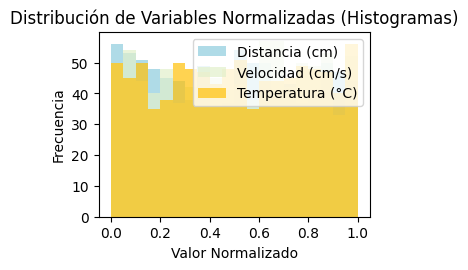

In [35]:
# 5. Visualizar los datos normalizados usando matplotlib
# Volvemos a los histogramas con colores diferenciados para cada variable.
plt.subplot(2, 2, 4) # Asegura que se dibuje en el mismo subplot

colors = ['#8ECDDD', '#E2F0CB', '#FFC107'] # Colores pastel: azul, verde, amarillo

for i, col in enumerate(numeric_cols):
    plt.hist(df_normalized[col], alpha=0.7, label=col, color=colors[i], bins=20) # Aumentar bins para más detalle

plt.title('Distribución de Variables Normalizadas (Histogramas)')
plt.xlabel('Valor Normalizado')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

Ejercicio 2.- Preguntas. Responder las siguientes preguntas:
1. ¿Cómo afecta la limpieza de datos al análisis del dataset?  
R = La limpieza de datos es esencial porque garantiza que el análisis se base en información precisa y coherente. Si el dataset contiene valores faltantes, duplicados o inconsistentes, los resultados pueden ser poco fiables. Al depurar registros erróneos (por ejemplo, lecturas imposibles de los sensores), se obtiene un conjunto de datos más fiel a la realidad y se evitan conclusiones engañosas.

2. ¿Por qué es importante la normalización en Machine Learning?  
R = La normalización es clave porque muchos algoritmos de aprendizaje automático dependen de que las variables numéricas estén en una escala comparable. Sin normalización, una variable con valores muy grandes puede dominar el modelo y sesgar los resultados. Al poner todas las variables en la misma escala, se mejora la eficiencia del entrenamiento y la calidad de las predicciones.

3. ¿Cómo interpretarías los datos visualizados?  
R = Los gráficos permiten comprender mejor el comportamiento de los sensores del robot. Se pueden detectar tendencias, como el aumento o disminución de la velocidad en ciertos intervalos, la estabilidad de la temperatura o la variación de la distancia con el tiempo. Al estar normalizados, los datos se pueden comparar directamente entre sí, lo que facilita descubrir relaciones, anomalías o patrones de funcionamiento del robot.